In [8]:
import matplotlib.pyplot as plt

def surface_code_grid(length=1):
    """
    Visualizes the static surface code grid.
    
    Parameters:
    - n: int, determines grid size (edge_len = 2*n + 1)
    """
    edge_len = 2 * length + 1
    
    # Generate positions (y inverted for plotting, row 0 at top)
    data_pos = [(j, -i) for i in range(edge_len) for j in range(edge_len) if i % 2 == j % 2]
    z_anc_pos = [(j, -i) for i in range(edge_len) for j in range(edge_len) if i % 2 == 0 and j % 2 == 1]
    x_anc_pos = [(j, -i) for i in range(edge_len) for j in range(edge_len) if i % 2 == 1 and j % 2 == 0]
    
    # Z connections: anc to datas (for lines)
    z_connections = {}
    for i in range(edge_len):
        for j in range(edge_len):
            if i % 2 == 0 and j % 2 == 1:  # Z ancilla
                anc_xy = (j, -i)
                datas = []
                if j - 1 >= 0: datas.append((j - 1, -i))  # left
                if j + 1 < edge_len: datas.append((j + 1, -i))  # right
                if i - 1 >= 0: datas.append((j, -(i - 1)))  # above
                if i + 1 < edge_len: datas.append((j, -(i + 1)))  # below
                z_connections[anc_xy] = datas
    
    # X connections: anc to datas
    x_connections = {}
    for i in range(edge_len):
        for j in range(edge_len):
            if i % 2 == 1 and j % 2 == 0:  # X ancilla
                anc_xy = (j, -i)
                datas = []
                if j - 1 >= 0: datas.append((j - 1, -i))  # left
                if j + 1 < edge_len: datas.append((j + 1, -i))  # right
                if i - 1 >= 0: datas.append((j, -(i - 1)))  # above
                if i + 1 < edge_len: datas.append((j, -(i + 1)))  # below
                x_connections[anc_xy] = datas
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-0.5, edge_len - 0.5)
    ax.set_ylim(-edge_len + 0.5, 0.5)
    ax.set_aspect('equal')
    ax.set_title(f'Surface Code Grid (n={n})')
    
    # Data qubits: open circles (empty, black edge)
    ax.scatter([p[0] for p in data_pos], [p[1] for p in data_pos], s=200, facecolors='none', edgecolors='black', marker='o', label='Data Qubits')
    
    # Z ancillas: filled dark green circles with 'Z' (white text for contrast)
    ax.scatter([p[0] for p in z_anc_pos], [p[1] for p in z_anc_pos], s=200, c='darkgreen', marker='o', label='Z Ancillas')
    for pos in z_anc_pos:
        ax.text(pos[0], pos[1], 'Z', ha='center', va='center', fontsize=12, color='white')
    
    # X ancillas: filled orange circles with 'X' (white text for contrast)
    ax.scatter([p[0] for p in x_anc_pos], [p[1] for p in x_anc_pos], s=200, c='darkorange', marker='o', label='X Ancillas')
    for pos in x_anc_pos:
        ax.text(pos[0], pos[1], 'X', ha='center', va='center', fontsize=12, color='white')
    
    # Static thin grey lines for all connections
    for conns in [z_connections, x_connections]:
        for anc, datas in conns.items():
            for d in datas:
                ax.plot([d[0], anc[0]], [d[1], anc[1]], lw=1, c='grey', zorder=0)
    
    plt.legend(loc='upper right')
    plt.show()



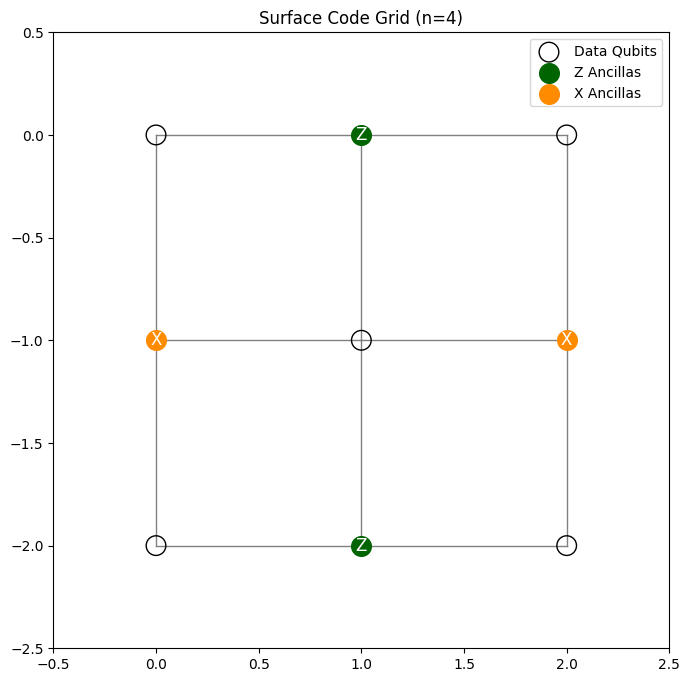

In [9]:

# Example call
surface_code_grid(length=1)

/var/folders/4m/ybdr7r2j2_nbh1ytdjdqr5v00000gn/T/ipykernel_45636/1552066139.py:27: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, _ in gates:


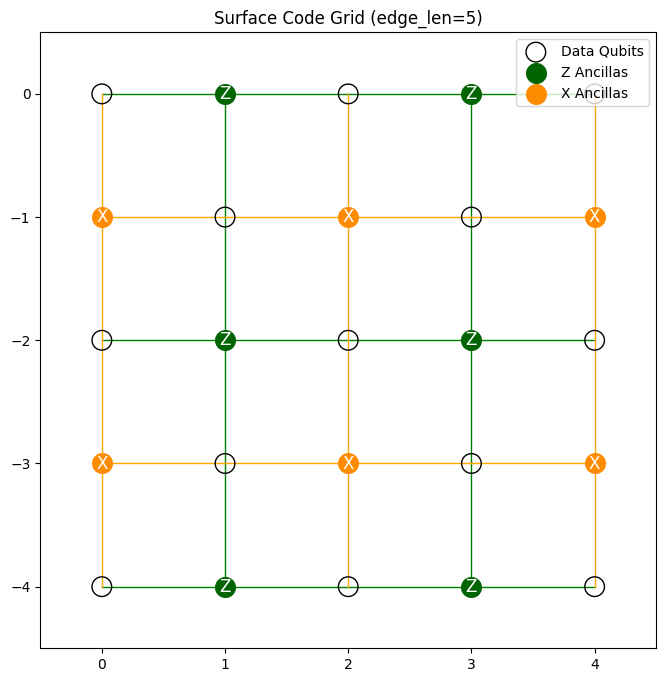

In [14]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
import math

def surface_code_grid(qc: QuantumCircuit):
    """
    Visualizes the static surface code grid based on the connections extracted from the provided quantum circuit.
    
    Parameters:
    - qc: QuantumCircuit, the quantum circuit from which to extract connections (CNOT gates).
    """
    total_len = qc.num_qubits
    edge_len = int(math.sqrt(total_len))
    if edge_len * edge_len != total_len:
        raise ValueError("The number of qubits must be a perfect square for a square grid.")
    
    # Generate positions (y inverted for plotting, row 0 at top)
    data_pos = [(j, -i) for i in range(edge_len) for j in range(edge_len) if i % 2 == j % 2]
    z_anc_pos = [(j, -i) for i in range(edge_len) for j in range(edge_len) if i % 2 == 0 and j % 2 == 1]
    x_anc_pos = [(j, -i) for i in range(edge_len) for j in range(edge_len) if i % 2 == 1 and j % 2 == 0]
    
    # Extract connections from the circuit's CNOT gates
    z_connections = {}  # Z anc (target) to datas (controls)
    x_connections = {}  # X anc (control) to datas (targets)
    
    gates = qc.data
    for instr, qargs, _ in gates:
        if instr.name == 'cx':
            control_idx = qc.find_bit(qargs[0]).index
            target_idx = qc.find_bit(qargs[1]).index
            i_c = control_idx // edge_len
            j_c = control_idx % edge_len
            i_t = target_idx // edge_len
            j_t = target_idx % edge_len
            
            # Check if it's a Z stabilizer connection (ancilla as target)
            if i_t % 2 == 0 and j_t % 2 == 1:  # Target is Z ancilla
                anc_xy = (j_t, -i_t)
                data_xy = (j_c, -i_c)
                if anc_xy not in z_connections:
                    z_connections[anc_xy] = []
                if data_xy not in z_connections[anc_xy]:
                    z_connections[anc_xy].append(data_xy)
            
            # Check if it's an X stabilizer connection (ancilla as control)
            elif i_c % 2 == 1 and j_c % 2 == 0:  # Control is X ancilla
                anc_xy = (j_c, -i_c)
                data_xy = (j_t, -i_t)
                if anc_xy not in x_connections:
                    x_connections[anc_xy] = []
                if data_xy not in x_connections[anc_xy]:
                    x_connections[anc_xy].append(data_xy)
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-0.5, edge_len - 0.5)
    ax.set_ylim(-edge_len + 0.5, 0.5)
    ax.set_aspect('equal')
    ax.set_title(f'Surface Code Grid (edge_len={edge_len})')
    
    # Data qubits: open circles (empty, black edge)
    ax.scatter([p[0] for p in data_pos], [p[1] for p in data_pos], s=200, facecolors='none', edgecolors='black', marker='o', label='Data Qubits')
    
    # Z ancillas: filled dark green circles with 'Z' (white text for contrast)
    ax.scatter([p[0] for p in z_anc_pos], [p[1] for p in z_anc_pos], s=200, c='darkgreen', marker='o', label='Z Ancillas')
    for pos in z_anc_pos:
        ax.text(pos[0], pos[1], 'Z', ha='center', va='center', fontsize=12, color='white')
    
    # X ancillas: filled orange circles with 'X' (white text for contrast)
    ax.scatter([p[0] for p in x_anc_pos], [p[1] for p in x_anc_pos], s=200, c='darkorange', marker='o', label='X Ancillas')
    for pos in x_anc_pos:
        ax.text(pos[0], pos[1], 'X', ha='center', va='center', fontsize=12, color='white')
    
    # Static colored lines for connections: green for Z, orange for X
    for anc, datas in z_connections.items():
        for d in datas:
            ax.plot([d[0], anc[0]], [d[1], anc[1]], lw=1, c='green', zorder=0)
    
    for anc, datas in x_connections.items():
        for d in datas:
            ax.plot([d[0], anc[0]], [d[1], anc[1]], lw=1, c='orange', zorder=0)
    
    plt.legend(loc='upper right')
    plt.show()

# Example usage with the provided circuit snippet
# Note: The provided code snippet is for initialization/stabilizers, adjust as needed
# For demonstration, let's create a sample qc based on the user's code

n = 2  # For small grid
edge_len = 2 * n + 1
total_len = edge_len * edge_len
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit
qreg = QuantumRegister(total_len, name="q")
# Dummy cregs, adjust as in user's code
init_creg = ClassicalRegister(total_len // 2, name="init")
data_creg = ClassicalRegister(total_len // 2 + 1, name="data")
qc = QuantumCircuit(qreg, init_creg, data_creg)  # Simplified, add more cregs if needed

# From user's code
for i in range(edge_len):
    for j in range(edge_len):
        if i % 2 != 0 and j % 2 == 0:
            # Odd row, even col — apply H and connect to neighbors if they exist
            anc = i * edge_len + j
            qc.h(anc)
            if j + 1 < edge_len:  # right neighbor
                qc.cx(anc, i * edge_len + (j + 1))
            if j - 1 >= 0:  # left neighbor
                qc.cx(anc, i * edge_len + (j - 1))
            if i + 1 < edge_len:  # below
                qc.cx(anc, (i + 1) * edge_len + j)
            if i - 1 >= 0:  # above
                qc.cx(anc, (i - 1) * edge_len + j)
            qc.h(anc)
        elif i % 2 == 0 and j % 2 == 1:
            # Even row, odd col — connect neighbors if they exist
            anc = i * edge_len + j
            if j + 1 < edge_len:  # right
                qc.cx(i * edge_len + (j + 1), anc)
            if j - 1 >= 0:  # left
                qc.cx(i * edge_len + (j - 1), anc)
            if i + 1 < edge_len:  # below
                qc.cx((i + 1) * edge_len + j, anc)
            if i - 1 >= 0:  # above
                qc.cx((i - 1) * edge_len + j, anc)

# Now visualize
surface_code_grid(qc)